# **CREDITOS OTORGADOS - PRODUBANCO**

# Objetivo del proyecto

El objetivo de este análisis es explorar el historial de créditos de los clientes para identificar patrones asociados al incumplimiento de pagos. A partir del análisis exploratorio y la ingeniería de variables se busca comprender qué características financieras o demográficas están asociadas con una mayor probabilidad de impago.

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [71]:
df=pd.read_csv("creditos_historicos.csv")

C:\Users\CltControl.GGIECLB1WRK209\AppData\Local\Temp\ipykernel_15064\3534307991.py:1: DtypeWarning: Columns (13,20) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("creditos_historicos.csv")


In [72]:
df

,id_cliente,loan_status,loan_amnt,installment,term,emp_title,emp_length,home_ownership,annual_inc,verification_status,...,next_pymnt_d,earliest_cr_line,mths_since_last_delinq,total_pymnt,recoveries,collection_recovery_fee,last_pymnt_d,settlement_status,application_type,tot_hi_cred_lim
0,0,Current,2500,84.92,36 months,Chef,10+ years,RENT,55000.0,Not Verified,...,Mar-2019,Apr-2001,NaN,167.020000,0.0,0.0,Feb-2019,NaN,Individual,60124.0
1,1,Current,30000,777.23,60 months,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,...,Mar-2019,Jun-1987,71.0,1507.110000,0.0,0.0,Feb-2019,NaN,Individual,372872.0
2,2,Current,5000,180.69,36 months,Administrative,6 years,MORTGAGE,59280.0,Source Verified,...,Mar-2019,Apr-2011,NaN,353.890000,0.0,0.0,Feb-2019,NaN,Individual,136927.0
3,3,Current,4000,146.51,36 months,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,...,Mar-2019,Feb-2006,NaN,286.710000,0.0,0.0,Feb-2019,NaN,Individual,385183.0
4,4,Current,30000,731.78,60 months,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,...,Mar-2019,Dec-2000,NaN,1423.210000,0.0,0.0,Feb-2019,NaN,Individual,157548.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260663,2260663,Current,12000,279.72,60 months,house keeper,10+ years,MORTGAGE,58000.0,Not Verified,...,Mar-2019,Jan-2004,NaN,5360.960000,0.0,0.0,Feb-2019,NaN,Individual,73948.0
2260664,2260664,Fully Paid,12000,358.01,60 months,Skilled Labor,< 1 year,MORTGAGE,30000.0,Not Verified,...,NaN,Mar-2003,13.0,14499.802172,0.0,0.0,Aug-2018,NaN,Joint App,382275.0
2260665,2260665,Current,10000,332.10,36 months,Teacher,10+ years,OWN,64000.0,Source Verified,...,Mar-2019,Feb-1995,NaN,5306.940000,0.0,0.0,Feb-2019,NaN,Individual,203417.0
2260666,2260666,Current,12000,327.69,60 months,NaN,NaN,RENT,60000.0,Not Verified,...,Mar-2019,Jul-2003,7.0,5207.290000,0.0,0.0,Feb-2019,NaN,Individual,118975.0


# **Parte 1** 

# Crear una definición de ‘mal_pagador’

**El dataset cuenta con varias columnas que hacen referencia los clientes que han tenido problemas de pagos. Analice y escoja una para crear la definición de mal pagador.**

In [73]:
df["loan_status"].value_counts(normalize=True)

loan_status
Fully Paid                                             0.460904
Current                                                0.406824
Charged Off                                            0.115742
Late (31-120 days)                                     0.009686
In Grace Period                                        0.003960
Late (16-30 days)                                      0.001653
Does not meet the credit policy. Status:Fully Paid     0.000879
Does not meet the credit policy. Status:Charged Off    0.000337
Default                                                0.000014
Name: proportion, dtype: float64

Para identificar a los clientes con comportamiento de riesgo se utilizó la variable loan_status.

Se clasificaron como malos pagadores aquellos créditos con estados asociados a incumplimiento o retrasos significativos, mientras que los créditos completamente pagados o en estado normal se clasificaron como buenos pagadores.

In [74]:
def mal_pagador(estado):
    if estado in ["Charged Off","Does not meet the credit policy. Status:Charged Off","Default","Late (31-120 days)"]:
        return 1 # mal pagador
    return 0     # buen pagador

In [75]:
df["mal_pagador"]=df["loan_status"].apply(mal_pagador)

# Data quality:

**Analice si existen valores duplicados, y si es así aborde el problema.**

**Analice si existen valores nulos, y si es así aborde el problema. Puede usar cualquiera de las alternativas que vimos en clase.**

**Si hay variables discretas que se encuentran como decimales, cámbielas a enteros. Por ejemplo, la edad en anos debe ser discreta.**

**Explore muy bien cuáles serían sus observaciones Válidas.**


In [76]:
# No hay clientes duplicados por lo tanto cada regitro corresponde a un cliente único
df["id_cliente"].duplicated().sum()

np.int64(0)

In [77]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 24 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   id_cliente               2260668 non-null  int64  
 1   loan_status              2260668 non-null  object 
 2   loan_amnt                2260668 non-null  int64  
 3   installment              2260668 non-null  float64
 4   term                     2260668 non-null  object 
 5   emp_title                2093699 non-null  object 
 6   emp_length               2113761 non-null  object 
 7   home_ownership           2260668 non-null  object 
 8   annual_inc               2260664 non-null  float64
 9   verification_status      2260668 non-null  object 
 10  purpose                  2260668 non-null  object 
 11  addr_state               2260668 non-null  object 
 12  delinq_2yrs              2260639 non-null  float64
 13  next_pymnt_d             957061 non-null  

In [78]:
# Corregimos el tipo de datos de algunas columnas 
df["id_cliente"]=df["id_cliente"].astype(str)

df["delinq_2yrs"] = pd.to_numeric(df["delinq_2yrs"], errors="coerce")

df["mths_since_last_delinq"] = pd.to_numeric(df["mths_since_last_delinq"], errors="coerce")

df["term"] = df["term"].str.extract("(\d+)")
df["term"] = pd.to_numeric(df["term"], errors="coerce")

df["emp_length"] = df["emp_length"].replace("< 1 year", "0 years")
df["emp_length"] = df["emp_length"].astype(str).str.extract("(\d+)")
df["emp_length"] = pd.to_numeric(df["emp_length"], errors="coerce")

In [79]:
# Consultamos el porcentaje de valores nulos por columna
df.isnull().sum()/df.shape[0]

id_cliente                 0.000000
loan_status                0.000000
loan_amnt                  0.000000
installment                0.000000
term                       0.000000
emp_title                  0.073858
emp_length                 0.064984
home_ownership             0.000000
annual_inc                 0.000002
verification_status        0.000000
purpose                    0.000000
addr_state                 0.000000
delinq_2yrs                0.000013
next_pymnt_d               0.576647
earliest_cr_line           0.000013
mths_since_last_delinq     0.512460
total_pymnt                0.000000
recoveries                 0.000000
collection_recovery_fee    0.000000
last_pymnt_d               0.001073
settlement_status          0.985378
application_type           0.000000
tot_hi_cred_lim            0.031086
mal_pagador                0.000000
dtype: float64

In [80]:
# Eliminamos la columna settlement_status porque el 98% son nulos, por lo que no aporta información significativa para el análisis
df=df.drop(columns=["settlement_status","next_pymnt_d"])

# Imputamos las columnas str con "Desconocido"
df["emp_title"]=df["emp_title"].fillna("desconocido")

# Tranformación de str a fecha e imputacion de datos con la mediana, excepto para "next_pymnt_d" ya que los null representan a los que terminaron o dejaron de pagar el crédito
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")
df["earliest_cr_line"] = df["earliest_cr_line"].fillna(df["earliest_cr_line"].median())

df["last_pymnt_d"] = pd.to_datetime(df["last_pymnt_d"], format="%b-%Y", errors="coerce")
df["last_pymnt_d"] = df["last_pymnt_d"].fillna(df["last_pymnt_d"].median())

# En los valores númericos imputamos con medianas, excepto "ths_since_last_delinq" porque los null representan a clientes sin ninguna mora por ende le pondremos -1
df["emp_length"]=df["emp_length"].fillna(df["emp_length"].median())
df["emp_length"]=df["emp_length"].astype(int)

df["annual_inc"] = df["annual_inc"].fillna(df["annual_inc"].median())

df["delinq_2yrs"] = df["delinq_2yrs"].fillna(df["delinq_2yrs"].median())
df["delinq_2yrs"]=df["delinq_2yrs"].astype(int)

df["tot_hi_cred_lim"] = df["tot_hi_cred_lim"].fillna(df["tot_hi_cred_lim"].median())

df["mths_since_last_delinq"].fillna(-1, inplace=True)
df["mths_since_last_delinq"] = df["mths_since_last_delinq"].astype(int)

C:\Users\CltControl.GGIECLB1WRK209\AppData\Local\Temp\ipykernel_15064\1152730785.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["mths_since_last_delinq"].fillna(-1, inplace=True)


In [81]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 22 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   id_cliente               2260668 non-null  object        
 1   loan_status              2260668 non-null  object        
 2   loan_amnt                2260668 non-null  int64         
 3   installment              2260668 non-null  float64       
 4   term                     2260668 non-null  int64         
 5   emp_title                2260668 non-null  object        
 6   emp_length               2260668 non-null  int64         
 7   home_ownership           2260668 non-null  object        
 8   annual_inc               2260668 non-null  float64       
 9   verification_status      2260668 non-null  object        
 10  purpose                  2260668 non-null  object        
 11  addr_state               2260668 non-null  object        
 12  

# **Parte 2**

# Feature transformation:

**En este apartado usted deberá crear nuevas columnas apartir de las que tiene. Pueden ser:**

**a) Variables indicadores (1 si cumple x condición, 0 caso contrario)** 

**b) Variables categóricas apartir de una variable nominal**

**c) Nuevas variables en funcion de otras, como por ejemplo ratios, vintage del cliente, etc..** 


VARIABLES INDICADORES

In [82]:
# Indicador de historial de mora (si alguna vez tuvo mora)
df["tuvo_mora"]=(df["mths_since_last_delinq"]>=0).astype(int)

# Indicador de ingresos
df["ingreso_alto"]=(df["annual_inc"]>df["annual_inc"].median()).astype(int)

# Indicador de empleo estable 
df["empleo_estable"]=(df["emp_length"]>=5).astype(int)

# Indicador vivienda propia
df["casa_propia"]=(df["home_ownership"]=="OWN").astype(int)

VARIABLES CATEGÓRICAS

In [83]:
# Categoría ingresos
df["categoria_ingreso"]=pd.qcut(df["annual_inc"], q=4, labels=["bajo","medio","alto","muy_alto"])

# Categoría de monto préstamo
df["categoria_prestamo"]=pd.qcut(df["loan_amnt"], q=3, labels=["bajo","medio","alto"])

# Categoría estabilidad laboral 
df["categoria_estabilidad_empleo"] = pd.cut(df["emp_length"], bins=[0,1,5,10],labels=["muy_baja","media","alta"])

RATIOS

In [84]:
# Tasa préstamo / ingreso
df["ratio_prestamo_ingreso"] = df["loan_amnt"] / df["annual_inc"]

# Tasa préstamo / límite de crédito
df["ratio_credito_limite"] = df["loan_amnt"] / df["tot_hi_cred_lim"]

## **Analisis correlacional:**

**1. Identifique si tiene variables correlacionadas.**

**2. En caso de ser así, encuentre una explicación lógica para esa correlación. Si no encuentra un argumento, puede mencionarlo.** 


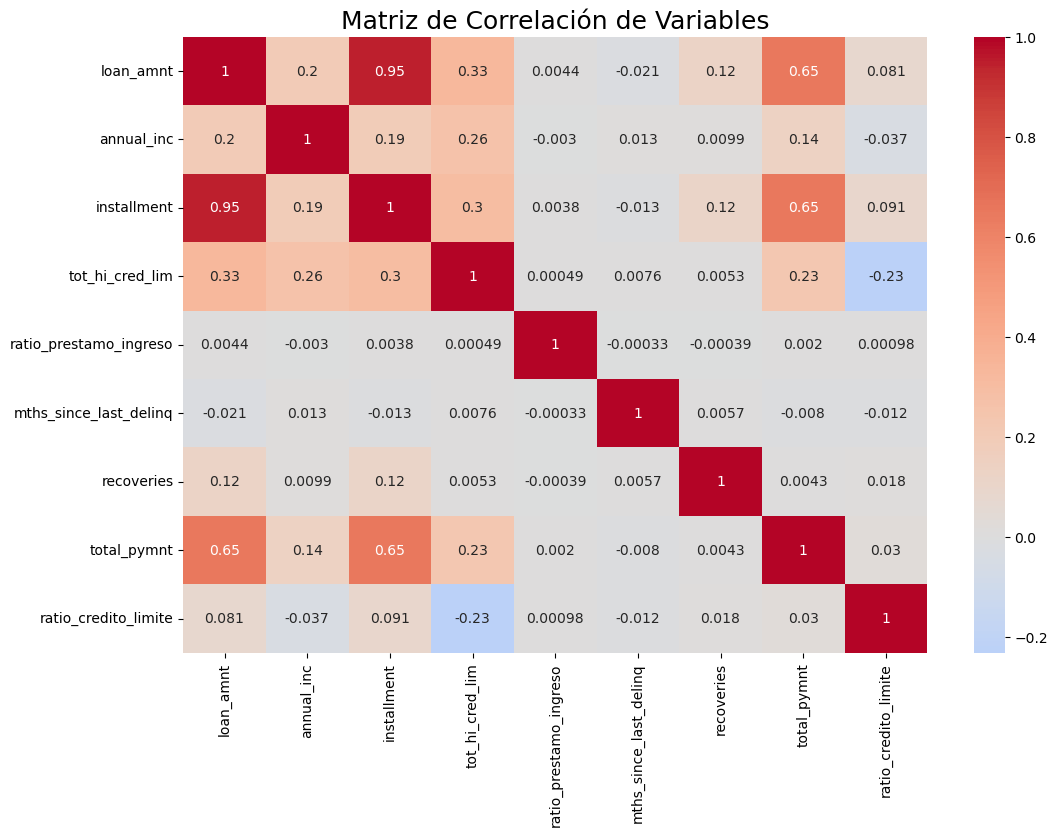

In [85]:
variables_continuas=["loan_amnt","annual_inc","installment","tot_hi_cred_lim","ratio_prestamo_ingreso","mths_since_last_delinq","recoveries","total_pymnt","ratio_credito_limite"]
corr=df[variables_continuas].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de Correlación de Variables", fontsize=18)
plt.show()

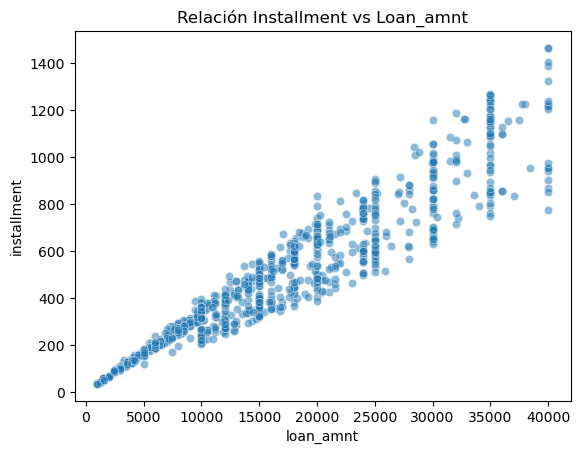

In [86]:
# installment vs loan amount
sns.scatterplot(data=df.sample(1000, random_state=200), x="loan_amnt", y="installment", alpha=0.5)
plt.title("Relación Installment vs Loan_amnt")
plt.show()

Después de realizar la correlación nos pudimos dar cuenta que "installment" y "loan_amnt" tienen demasiada relación (0.95) ya que tiene sentido que en base a la cantidad del crédito se establece la cuota por ende se ha decidido eliminar la columna "installment".

In [87]:
df=df.drop(columns=["installment"])

## **Análisis descriptivo:**

**1. Usando estatísticos descriptivos univariados, analice las variables que considere relevantes y aportan información.** 

**2. Usando estatísticos descriptivos bivariados, analice las variables que considere relevantes y aportan información.** 

**3. Con variables categóricas, realice análisis con tablas cruzadas.** 


UNIVARIADOS

**Pregunta: El monto del préstamo influye en el comportamiento de pago de los clientes?**

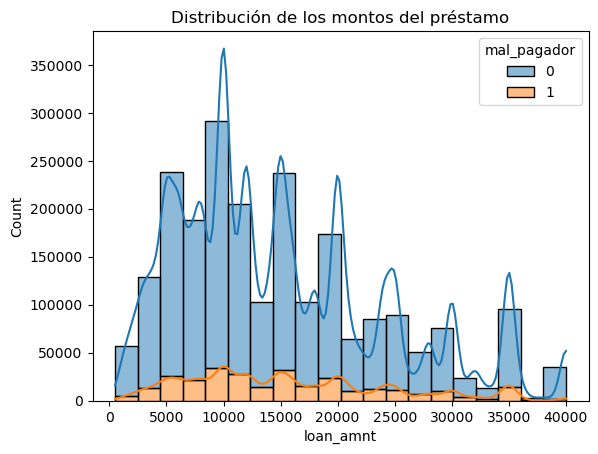

In [88]:
# Distribución de los montos del préstamo
sns.histplot(df, x="loan_amnt", hue="mal_pagador", bins=20, multiple="stack", kde=True)
plt.title("Distribución de los montos del préstamo")
plt.show()

El histograma muestra que la mayoría de los préstamos se concentran entre $5,000 y $15,000, disminuyendo notablemente para montos mayores a $20,000. Además, el dataset presenta desbalance de clases, ya que predominan los buenos pagadores. Finalmente, se aprecia que los préstamos de mayor monto podrían tener una proporción ligeramente mayor de riesgo de impago.

**Pregunta: Cómo influyen los ingresos de los clientes al comportamiento de pagos?**

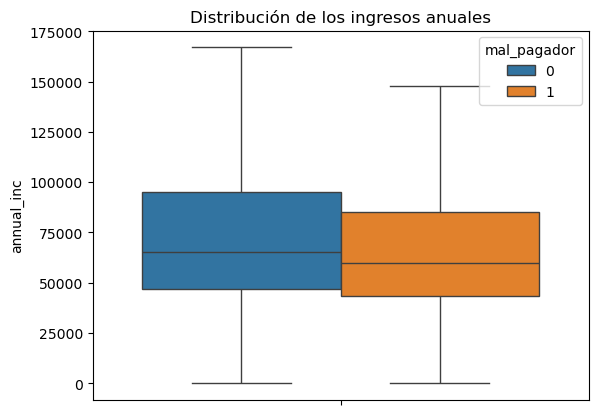

In [89]:
# Distribución de los ingresos anuales
sns.boxplot(df, y="annual_inc", hue="mal_pagador", showfliers=False)
plt.title("Distribución de los ingresos anuales")
plt.show()

La mediana de ingresos de los buenos pagadores (0) es ligeramente mayor que la de los malos pagadores (1), lo que sugiere que quienes tienen mayores ingresos tienden a cumplir mejor con sus pagos. Sin embargo, los rangos intercuartílicos son bastante similares, indicando que ambos grupos comparten niveles de ingreso comparables. También se observa una mayor dispersión en los buenos pagadores, con ingresos máximos más altos, lo que podría indicar que los clientes con mayores ingresos presentan menor riesgo de impago.

**Pregunta: Como se relaciona el ratio prestamo ingreso con el comportamiento de pago de los clientes?**

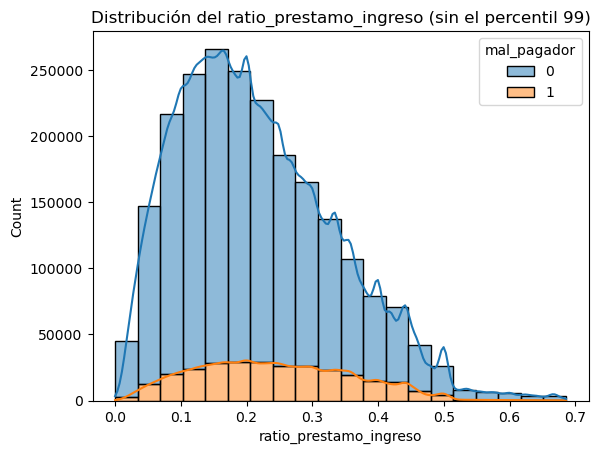

In [90]:
# Distribución del ratio_prestamo_ingreso excluyendo el percentil 99 para evitar outliers
limite = df["ratio_prestamo_ingreso"].quantile(0.99)
sns.histplot(df, x=df[df["ratio_prestamo_ingreso"] <= limite]["ratio_prestamo_ingreso"], bins=20, hue="mal_pagador", multiple="stack", kde=True)
plt.title("Distribución del ratio_prestamo_ingreso (sin el percentil 99)")
plt.show()

El histograma muestra que la mayoría de los préstamos tienen un ratio préstamo/ingreso anual entre 0.1 y 0.3, lo que indica que generalmente representan entre el 10% y 30% de los ingresos del cliente. La distribución presenta asimetría positiva, con pocos casos de ratios altos (mayores a 0.5). Sin embargo, a medida que el ratio aumenta, la proporción de malos pagadores tiende a incrementarse, sugiriendo mayor riesgo de impago.

BIVARIADOS

**Pregunta: Existe relación entre el ingreso anual y el monto del préstamo?**

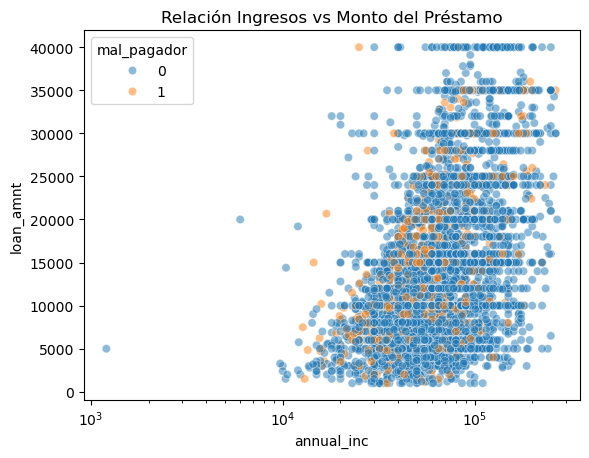

In [91]:
# Ingreso anual vs monto del préstamo
df_filtrado=df[df["annual_inc"]<=df["annual_inc"].quantile(0.99)]
sns.scatterplot(data=df_filtrado.sample(5000, random_state=42), x="annual_inc", y="loan_amnt", hue="mal_pagador", alpha=0.5)
plt.xscale('log')
plt.title("Relación Ingresos vs Monto del Préstamo")
plt.show()

El gráfico de dispersión entre ingreso anual y monto del préstamo muestra una alta dispersión de los datos, lo que indica que no existe una relación lineal fuerte entre ambas variables. Es decir, solo con el ingreso anual y el monto del préstamo no se distingue claramente el riesgo de incumplimiento.

**Pregunta: Cómo es la relación de la estabilidad laboral frente a los ingreos?**

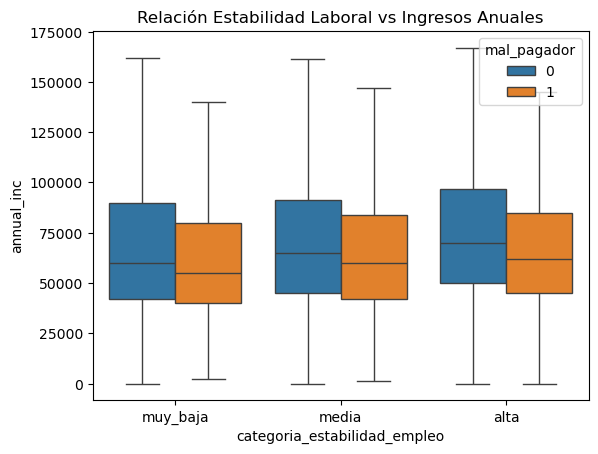

In [92]:
# Estabilidad laboral vs ingresos anuales
sns.boxplot(x="categoria_estabilidad_empleo", y="annual_inc", data=df, hue="mal_pagador", showfliers=False)
plt.title("Relación Estabilidad Laboral vs Ingresos Anuales")
plt.show()

El boxplot muestra que los buenos pagadores presentan ingresos medianos más altos que los malos pagadores en todas las categorías de estabilidad laboral. Además, a mayor estabilidad laboral, mayor tiende a ser el nivel de ingresos, lo que sugiere que los empleos más estables suelen estar mejor remunerados. Finalmente, incluso dentro de la categoría de alta estabilidad, los clientes que incumplen pagos tienen ingresos medianos más bajos, indicando que el nivel de ingresos es un factor clave en el riesgo de impago.

**Pregunta: Como es la Tasa de Impago con respecto al tipo de vivienda?**

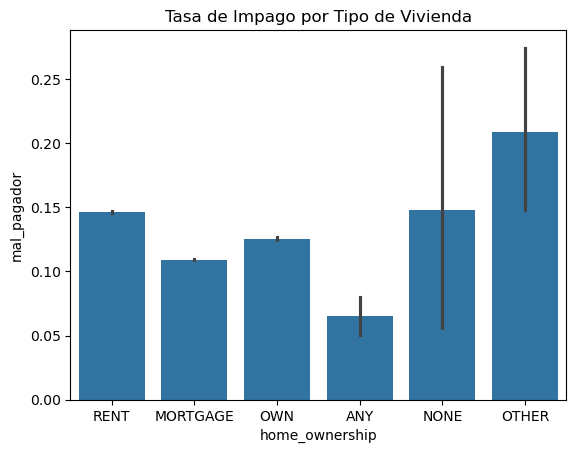

In [93]:
# Tasa de Impago por Tipo de Vivienda
sns.barplot(data=df, x="home_ownership", y="mal_pagador")
plt.title("Tasa de Impago por Tipo de Vivienda")
plt.show()

El gráfico muestra que los clientes que rentan (RENT) presentan la mayor tasa de impago, cercana al 15%, mientras que quienes tienen hipoteca (MORTGAGE) registran un riesgo menor, alrededor del 11%. Los propietarios de vivienda (OWN) presentan un riesgo intermedio cercano al 12.5%. En cambio, las categorías ANY, NONE y OTHER presentan intervalos de confianza amplios, lo que sugiere pocos datos y baja confiabilidad estadística en esas estimaciones.

**Pregunta: Como es la relación del Tipo de Aplicación con respecto al monto del préstamo?**

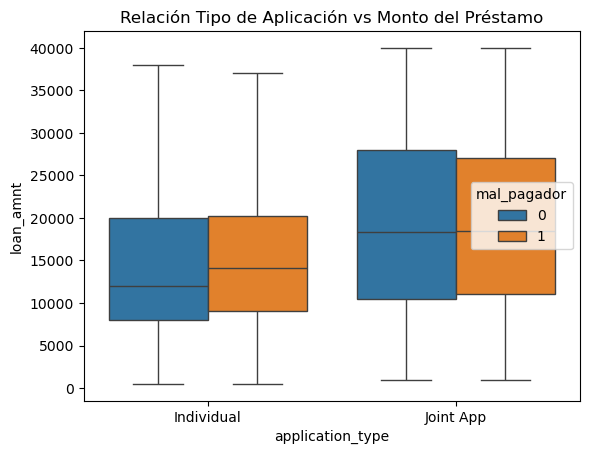

In [94]:
# Relación Tipo de Aplicación vs Monto del Préstamo 
sns.boxplot(df, x="application_type", y="loan_amnt", hue="mal_pagador", showfliers=False)
plt.title("Relación Tipo de Aplicación vs Monto del Préstamo")
plt.show()

Al analizar el monto del préstamo según el tipo de aplicación y el comportamiento de pago, se observa que los clientes clasificados como malos pagadores tienden a presentar medianas de préstamo ligeramente superiores en ambos tipos de solicitud. Sin embargo, las distribuciones de montos entre buenos y malos pagadores se superponen considerablemente, lo que sugiere que el monto del préstamo por sí solo no es un factor determinante del impago.

TABLAS CRUZADAS

**Pregunta: Qué profesión es la más probable que no pague el préstamo?**

In [95]:
def categorizar_empleo(title):

    if pd.isna(title):
        return "Other"
    
    title = title.lower()

    if any(x in title for x in ["manager","director","vp","vice president","chief","president","head","supervisor"]):
        return "Management"

    elif any(x in title for x in ["finance","account","bank","credit","loan","underwriter","treasury","billing"]):
        return "Finance"

    elif any(x in title for x in ["software","developer","data","network","systems","cyber","it","security","programmer"]):
        return "IT"

    elif any(x in title for x in ["engineer","engineering","mechanic","maintenance","technical"]):
        return "Engineering"

    elif any(x in title for x in ["nurse","physician","medical","clinic","hospital","therap","health"]):
        return "Healthcare"

    elif any(x in title for x in ["teacher","professor","school","education","instructor","research"]):
        return "Education"

    elif any(x in title for x in ["sales","marketing","account manager","business development","consultant"]):
        return "Sales_Marketing"

    elif any(x in title for x in ["customer","support","service","helpdesk","call center"]):
        return "Customer_Service"

    elif any(x in title for x in ["assistant","administrator","secretary","clerk","office"]):
        return "Administrative"

    elif any(x in title for x in ["operations","logistics","warehouse","supply","coordinator"]):
        return "Operations"

    elif any(x in title for x in ["electrician","plumber","hvac","construction","installer","operator"]):
        return "Skilled_Trades"

    elif any(x in title for x in ["chef","cook","restaurant","hotel","bartender","retail","cashier"]):
        return "Hospitality_Retail"

    elif any(x in title for x in ["police","sheriff","army","military","officer","security","investigator"]):
        return "Government_Military"

    elif any(x in title for x in ["driver","pilot","transport","delivery","aviation"]):
        return "Transportation"

    else:
        return "Other"

In [96]:
df["emp_category"] = df["emp_title"].apply(categorizar_empleo)


In [97]:
# Tabla cruzada categoria de profesion y mal pagador    
pd.crosstab(df["emp_category"], df["mal_pagador"], normalize="index")

mal_pagador,0,1
emp_category,,
Administrative,0.877432,0.122568
Customer_Service,0.859296,0.140704
Education,0.888553,0.111447
Engineering,0.890522,0.109478
Finance,0.878975,0.121025
Government_Military,0.879533,0.120467
Healthcare,0.879083,0.120917
Hospitality_Retail,0.848560,0.151440
IT,0.884335,0.115665


La tabla cruzada entre la categoría profesional y el comportamiento de pago muestra diferencias moderadas en la tasa de impago entre sectores laborales. Las categorías relacionadas con transporte, hospitalidad y oficios técnicos presentan mayores proporciones de clientes clasificados como malos pagadores, superando el 14%. En contraste, sectores como ingeniería, educación y tecnología muestran tasas de impago más bajas, cercanas al 11%. Esto sugiere que la estabilidad laboral y el nivel de ingresos asociados a ciertas profesiones podrían influir en el riesgo crediticio.

**Pregunta: Qué propósito del crédito es la más propensa a impagos?**

In [98]:
# Tabla cruzada Propósito del crédito y mal pagador
pd.crosstab(df["purpose"], df["mal_pagador"], normalize="index")

mal_pagador,0,1
purpose,,
car,0.904635,0.095365
credit_card,0.897853,0.102147
debt_consolidation,0.863848,0.136152
educational,0.792453,0.207547
home_improvement,0.889623,0.110377
house,0.877264,0.122736
major_purchase,0.882882,0.117118
medical,0.867870,0.132130
moving,0.847238,0.152762


Existe una brecha de riesgo de más del 11% entre los préstamos para vehículos y los educativos. La política de crédito debería endurecerse para los sectores Educativo y Pymes (Small Business), mientras que se podrían ofrecer tasas más competitivas para Vehículos y Mejoras de Vivienda por su alta tasa de retorno

# Conclusiones y recomendaciones

**Conclusiones**

• La construcción de la variable mal_pagador a partir del estado del crédito permitió clasificar a los clientes según su comportamiento de pago, facilitando el análisis del riesgo crediticio dentro del conjunto de datos.

• El análisis de las variables financieras evidenció que indicadores como el ratio préstamo-ingreso permiten aproximarse a la capacidad de pago de los clientes y pueden contribuir a identificar niveles elevados de endeudamiento.

• Se identificó una alta correlación entre algunas variables financieras, como loan_amnt e installment, lo cual sugiere redundancia en la información y justifica la selección de variables más representativas para futuros análisis o modelos.

• El análisis exploratorio permitió identificar patrones en el comportamiento de pago de los clientes, proporcionando una base útil para el desarrollo de modelos predictivos orientados a la evaluación del riesgo crediticio.

**Recomendaciones**

• Se recomienda incorporar indicadores financieros derivados, como el ratio préstamo-ingreso, dentro de los procesos de análisis de riesgo, ya que permiten evaluar de forma más clara la carga financiera de los clientes.

• Se sugiere mejorar la calidad y consistencia de los datos históricos, reduciendo la presencia de valores nulos o variables con baja disponibilidad de información para fortalecer futuros análisis.

• Para ampliar el alcance del proyecto, se recomienda desarrollar modelos de clasificación que permitan estimar la probabilidad de impago de los clientes a partir de las variables identificadas como más relevantes.

• Finalmente, se recomienda realizar análisis periódicos del comportamiento crediticio con el fin de identificar cambios en los patrones de pago y apoyar la toma de decisiones en la gestión del riesgo.